# Project 2. Classification Network

## Dataset

We're going to use the CIFAR10 dataset for this project.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Subset, DataLoader
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt
import signal
import time
from sklearn.metrics import precision_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image transform
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load CIFAR-10
full_training_data = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=data_transform)
test_data = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=data_transform)

# Build Non-IID split: classes 0–4 get 2500, 5–9 get 5000
label_to_indices = defaultdict(list)
for idx, label in enumerate(full_training_data.targets):
    label_to_indices[label].append(idx)

balanced_indices = []
for class_id in range(10):
    count = 2500 if class_id < 5 else 5000
    balanced_indices.extend(label_to_indices[class_id][:count])

non_iid_training_data = Subset(full_training_data, balanced_indices)

# Dataset summary
print("Non-IID CIFAR-10:")
print(f"- Training: {len(non_iid_training_data)} samples")
print(f"- Test: {len(test_data)} samples")


Non-IID CIFAR-10:
- Training: 37500 samples
- Test: 10000 samples


# Task1: CIFAR-10 Training

### Data distribution
Each team should select **ONE** of the following data distributions:
1. IID Data Distribution

Ensure that the training dataset follows an IID (Independent and Identically Distributed) pattern—i.e., an equal number of samples for each class.
i.e., 5000 images for each class.

2. Non-IID Data Distribution

Use a non-IID training data setup. Specifically, the number of images in Classes 0–4 should be half the number in Classes 5–9.
i.e., 2500 images for each Classes 0–4; 2500*2 images for each Classes 5–9,



Note: Your training loop must include the class distribution check before training begins, in the same code cell.

In [2]:
subset_targets = [full_training_data.targets[i] for i in balanced_indices]
class_counts = Counter(subset_targets)

print("Class counts in training set:")
for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

# CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Init model
model = SimpleCNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
trainloader = DataLoader(non_iid_training_data, batch_size=64, shuffle=True)

# Train
hit_60 = hit_70 = hit_80 = False

for epoch in range(1, 11):
    total = correct = 0
    total_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    acc = correct / total
    print(f"Epoch [{epoch}/10], Loss: {total_loss:.4f}, Accuracy: {acc:.4f}")

    if not hit_60 and acc >= 0.6:
        print("Hit 60%")
        hit_60 = True
    if not hit_70 and acc >= 0.7:
        print("Hit 70%")
        hit_70 = True
    if not hit_80 and acc >= 0.8:
        print("Hit 80%")
        hit_80 = True

print("Training done.")


Class counts in training set:
Class 0: 2500
Class 1: 2500
Class 2: 2500
Class 3: 2500
Class 4: 2500
Class 5: 5000
Class 6: 5000
Class 7: 5000
Class 8: 5000
Class 9: 5000
Epoch [1/10], Loss: 782.6452, Accuracy: 0.5322
Epoch [2/10], Loss: 562.6232, Accuracy: 0.6667
Hit 60%
Epoch [3/10], Loss: 471.8317, Accuracy: 0.7227
Hit 70%
Epoch [4/10], Loss: 409.9791, Accuracy: 0.7568
Epoch [5/10], Loss: 355.3156, Accuracy: 0.7900
Epoch [6/10], Loss: 304.3753, Accuracy: 0.8197
Hit 80%
Epoch [7/10], Loss: 256.8526, Accuracy: 0.8490
Epoch [8/10], Loss: 214.4186, Accuracy: 0.8737
Epoch [9/10], Loss: 170.7694, Accuracy: 0.9002
Epoch [10/10], Loss: 134.4484, Accuracy: 0.9214
Training done.


## Challenge

Make your network converges above 0.7 precision (to the point that it is clear your precision will converge over 0.7) in **1 minutes** with **T4 GPU**. (draw precision plot as proof)

Use the following command to make sure you're using T4 GPU

In [3]:
!nvidia-smi

Sun May  4 07:14:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P0             33W /   70W |     220MiB /  15360MiB |     18%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Preparation: TimeLimitation Function:

Timer set to 60 seconds
Epoch [1/10], Loss: 773.3512, Accuracy: 0.5427, Precision: 0.5076
Epoch [2/10], Loss: 553.4643, Accuracy: 0.6730, Precision: 0.6373
Epoch [3/10], Loss: 469.2210, Accuracy: 0.7213, Precision: 0.6901
Epoch [4/10], Loss: 405.4533, Accuracy: 0.7609, Precision: 0.7316
Epoch [5/10], Loss: 348.6087, Accuracy: 0.7940, Precision: 0.7686
Time's up — training stopped.


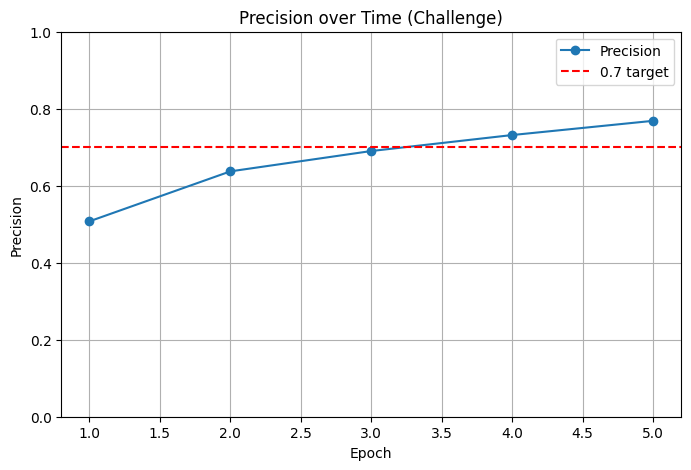

In [4]:
# Timer class
class TimeLimitation:
    def __init__(self, limit):
        self.limit = limit
    def __enter__(self):
        def handler(signum, frame):
            raise NotImplementedError("Time's up")
        signal.signal(signal.SIGALRM, handler)
        signal.alarm(self.limit)
    def __exit__(self, exc_type, exc_val, exc_tb):
        signal.alarm(0)

# Start timed run
time_limit = 60
print(f"Timer set to {time_limit} seconds")

precision_vals = []

try:
    with TimeLimitation(time_limit):

        # Fresh model
        model = SimpleCNN().to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        for epoch in range(1, 11):
            preds_all = []
            labels_all = []
            total_loss = 0.0
            total = correct = 0

            for inputs, labels in trainloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = loss_fn(outputs, labels)
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
                preds_all += preds.cpu().tolist()
                labels_all += labels.cpu().tolist()

            acc = correct / total
            prec = precision_score(labels_all, preds_all, average='macro')
            precision_vals.append(prec)

            print(f"Epoch [{epoch}/10], Loss: {total_loss:.4f}, Accuracy: {acc:.4f}, Precision: {prec:.4f}")

except NotImplementedError:
    print("Time's up — training stopped.")


# Plot precision
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(precision_vals)+1), precision_vals, marker='o', label='Precision')
plt.axhline(0.7, color='red', linestyle='--', label='0.7 target')
plt.title("Precision over Time (Challenge)")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()


## Task2: Questions  

Answer the following questions based on your experiments.

Question 1 : Why does non-IID data distribution drive a degrade in learning performance? What other factories could also result in performance degradation? Why?

Answer: Non-IID data distribution leads to performance degradation because it creates class imbalance which leads the model to overfit dominant classes and under-learn minority classes. Other factors include high learning rate, poor architecture, noisy data, or insufficient training time — all of which disrupt smooth convergence and lead to lower accuracy.

Question 2 : What kind of neural network architecture(s) is more suitable for learning in a limited time? (consider the challenge) Why?

Answer:  The most suitable models for limited-time training are lightweight convolutional networks or residual architectures such as  ResNet. These models achieve a balance between performance and speed by allowing faster convergence while maintaining accuracy. The  integration of batch normalization enhances training stability which enables the network to achieve performance targets within limited time  constraints.

# Marking Scheme

* Complete and run the full training pipeline:	10%
* Achieve test accuracy above 0.60 with IID (or with Non-IID) data distribution:	10%(+5%)
* Achieve test accuracy above 0.70 with IID (or with Non-IID) data distribution:	10%(+5%)
* Achieve test accuracy above 0.80 with IID (or with Non-IID) data distribution:	10%(+5%)
* Complete Challenge (1-minute training):	10%
* Clear code and well-organized submission:	15%
*  2 questions	20%